In [1]:
from google.colab import files

# Upload
uploaded = files.upload()

Saving Time_Series_Data.csv to Time_Series_Data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [5]:
import pandas as pd
df = pd.read_csv('Time_Series_Data.csv')

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^0-9a-zA-Z_]', '', regex=True)
df.head()

,name,date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,stations,yearmonth,month,sunrise2,sunset3,sunrise_time,sunset_time,sunset_time4,daylight,hoursmin
0,Gujarat,01-01-2015,26.1,12.7,19.0,0.0,0.0,27.9,9.1,55.8,...,NaN,2015,Jan,2015-01-01 07:20:52,2015-01-0118:04:47,07:20:52,2015-01-01T18:04:47,18:04:47,10:43:55,10:43
1,Gujarat,02-01-2015,26.4,12.9,19.2,0.0,0.0,27.9,9.2,55.7,...,NaN,2015,Jan,2015-01-02 07:21:10,2015-01-0218:05:26,07:21:10,2015-01-02T18:05:26,18:05:26,10:44:16,10:44
2,Gujarat,03-01-2015,26.7,13.7,19.5,0.0,0.0,27.6,9.3,54.7,...,NaN,2015,Jan,2015-01-03 07:21:27,2015-01-0318:06:05,07:21:27,2015-01-03T18:06:05,18:06:05,10:44:38,10:44
3,Gujarat,04-01-2015,27.0,13.1,19.2,0.0,0.0,27.4,9.0,55.0,...,NaN,2015,Jan,2015-01-04 07:21:43,2015-01-0418:06:45,07:21:43,2015-01-04T18:06:45,18:06:45,10:45:02,10:45
4,Gujarat,05-01-2015,27.3,12.8,19.4,0.0,0.0,27.4,8.5,53.1,...,NaN,2015,Jan,2015-01-05 07:21:57,2015-01-0518:07:25,07:21:57,2015-01-05T18:07:25,18:07:25,10:45:28,10:45


In [7]:
# Try common date column names
date_cols = [c for c in df.columns if 'date' in c]
print("date candidate columns:", date_cols)

# Use first candidate as datetime index
df['date'] = pd.to_datetime(df[date_cols[0]], errors='coerce')
df = df.set_index('date').sort_index()

# Quick info
print(df.index.min(), df.index.max())
print(df.shape)
print(df.info())

# Missing value overview
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

date candidate columns: ['date']
2015-01-01 00:00:00 2025-12-07 00:00:00
(3865, 41)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3865 entries, 2015-01-01 to NaT
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3865 non-null   object 
 1   tempmax           3865 non-null   float64
 2   tempmin           3865 non-null   float64
 3   temp              3865 non-null   float64
 4   feelslikemax      3865 non-null   float64
 5   feelslikemin      3865 non-null   float64
 6   feelslike         3865 non-null   float64
 7   dew               3865 non-null   float64
 8   humidity          3865 non-null   float64
 9   precip            3865 non-null   float64
 10  precipprob        3865 non-null   float64
 11  precipcover       3865 non-null   float64
 12  preciptype        658 non-null    object 
 13  snow              2891 non-null   float64
 14  snowdepth         2891 non-null   float64

,0
preciptype,3207
severerisk,2641
stations,1642
snowdepth,974
description,974
snow,974


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
preciptype,3207
severerisk,2641
stations,1642
snowdepth,974
description,974
snow,974
tempmin,0
tempmax,0
name,0
humidity,0


In [9]:
df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,...,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase,yearmonth
count,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,...,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,3865.000000,1224.000000,3865.000000,3865.000000
mean,34.225589,22.492264,27.876067,27.826210,17.512497,31.592497,16.862924,56.469237,2.347995,15.002536,...,184.764580,1008.385692,29.166261,4.440906,221.096973,19.087529,7.719276,16.013072,0.483565,2019.802070
std,5.006062,5.523251,4.856499,17.384914,11.717997,7.184333,6.894637,17.717481,9.356023,34.558951,...,99.016262,5.486465,29.724548,0.948986,63.704052,5.506205,1.840313,12.921354,0.288741,3.061041
min,18.500000,7.000000,14.700000,0.000000,0.000000,14.700000,-2.400000,15.400000,0.000000,0.000000,...,0.100000,993.400000,0.000000,1.800000,0.000000,0.000000,0.000000,5.000000,0.000000,2015.000000
25%,31.000000,17.800000,24.200000,0.000000,0.000000,26.200000,10.700000,43.200000,0.000000,0.000000,...,79.500000,1003.700000,4.200000,4.100000,188.800000,16.300000,7.000000,10.000000,0.250000,2017.000000
50%,34.000000,24.800000,28.700000,33.000000,20.000000,32.000000,16.300000,53.200000,0.000000,0.000000,...,220.900000,1008.500000,15.600000,4.400000,219.800000,19.000000,8.000000,10.000000,0.500000,2020.000000
75%,38.000000,27.000000,31.400000,41.400000,26.000000,37.500000,24.000000,72.100000,0.100000,0.000000,...,253.000000,1013.100000,52.800000,4.700000,270.100000,23.400000,9.000000,10.000000,0.750000,2022.000000
max,48.000000,32.300000,39.200000,59.200000,40.100000,48.100000,29.600000,99.500000,185.400000,100.000000,...,359.600000,1022.300000,100.000000,17.800000,332.300000,28.700000,10.000000,100.000000,0.980000,2025.000000


In [11]:
outliers = {}
num_cols = df.select_dtypes(include=np.number).columns.tolist() # Define num_cols
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    mask = (df[c] < lower) | (df[c] > upper)
    outliers[c] = mask.sum()
    # Optional: you can cap (winsorize) or keep but flag
pd.Series(outliers).sort_values(ascending=False)

,0
precip,880
precipcover,880
precipprob,880
severerisk,292
visibility,179
uvindex,141
solarradiation,101
windspeed,100
solarenergy,98
windgust,43


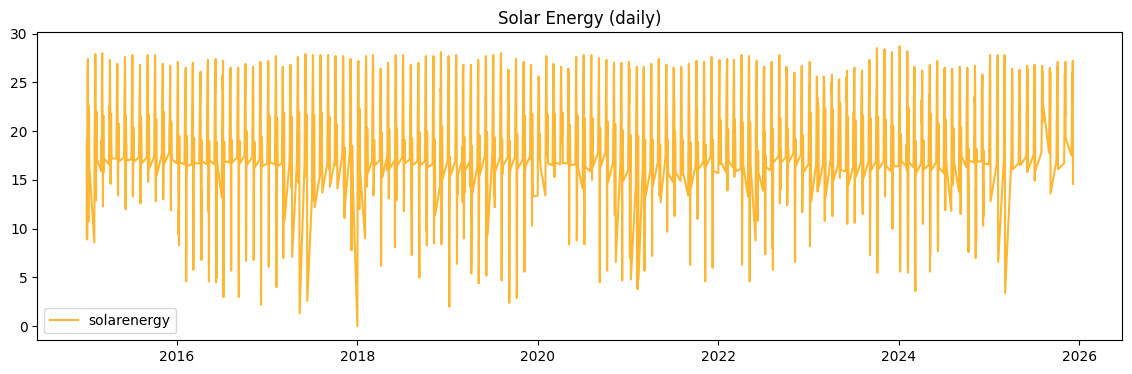

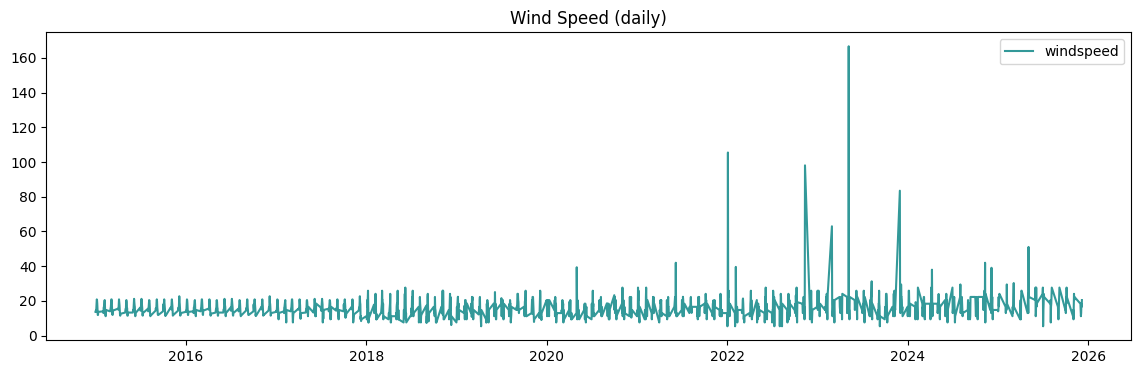

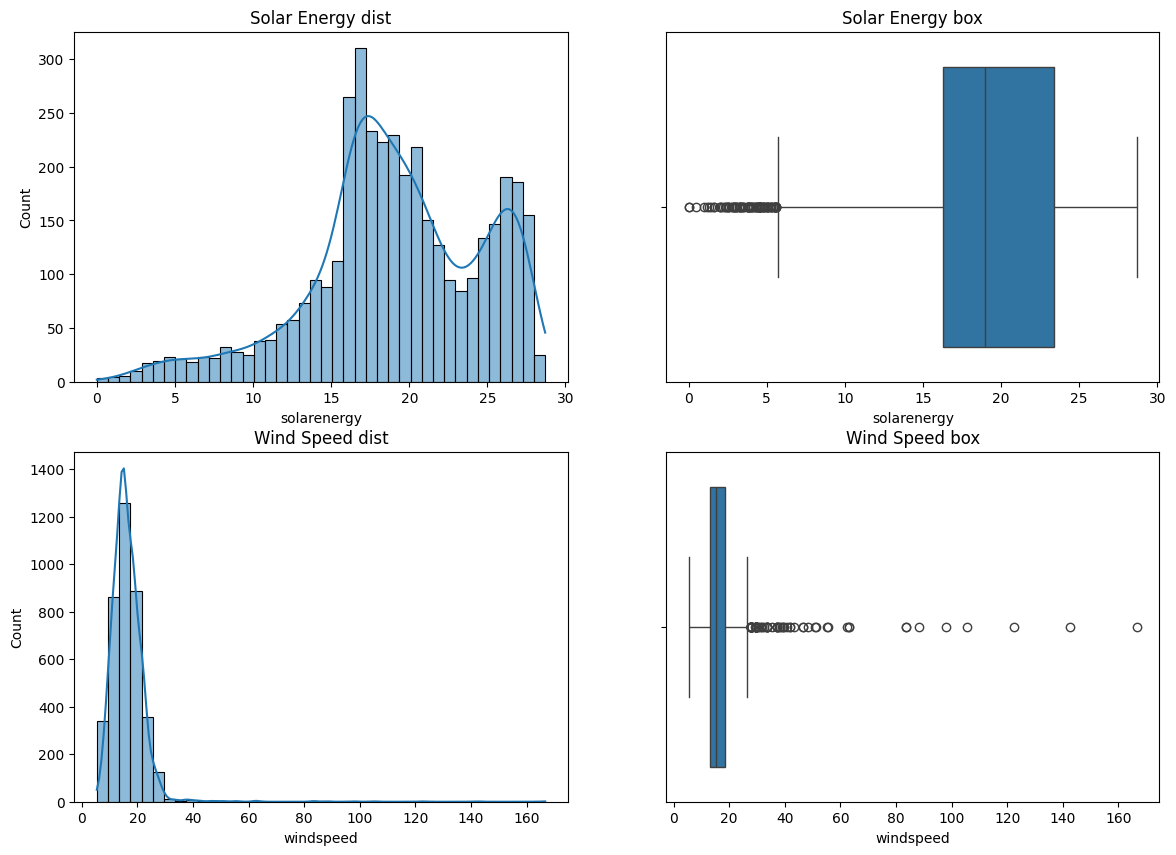

In [12]:
# Time plots (daily)
plt.figure(figsize=(14,4))
plt.plot(df.index, df['solarenergy'], label='solarenergy', color='orange', alpha=0.8)
plt.title('Solar Energy (daily)')
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['windspeed'], label='windspeed', color='teal', alpha=0.8)
plt.title('Wind Speed (daily)')
plt.legend()
plt.show()

# Distribution + boxplot
fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.histplot(df['solarenergy'].dropna(), bins=40, ax=axes[0,0], kde=True).set_title('Solar Energy dist')
sns.boxplot(x=df['solarenergy'].dropna(), ax=axes[0,1]).set_title('Solar Energy box')
sns.histplot(df['windspeed'].dropna(), bins=40, ax=axes[1,0], kde=True).set_title('Wind Speed dist')
sns.boxplot(x=df['windspeed'].dropna(), ax=axes[1,1]).set_title('Wind Speed box')
plt.show()

/tmp/ipython-input-2422336008.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df[num_cols].resample('M').mean()


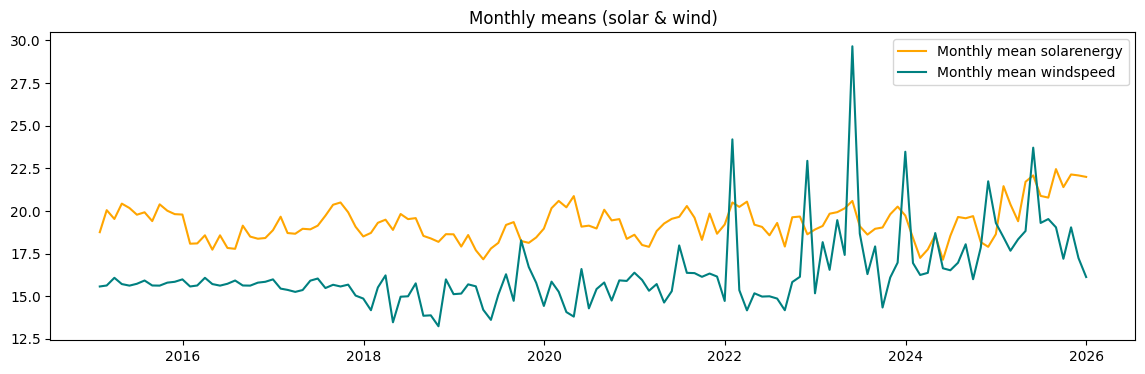

In [13]:
# Resample to monthly mean (for classical trend/seasonal methods)
monthly = df[num_cols].resample('M').mean()
monthly = monthly.dropna(how='all')
monthly.head()

# Quick month-line plot (120 points if 10 years)
plt.figure(figsize=(14,4))
plt.plot(monthly.index, monthly['solarenergy'], label='Monthly mean solarenergy', color='orange')
plt.plot(monthly.index, monthly['windspeed'], label='Monthly mean windspeed', color='teal')
plt.legend()
plt.title('Monthly means (solar & wind)')
plt.show()


/tmp/ipython-input-2257257763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df.index.month


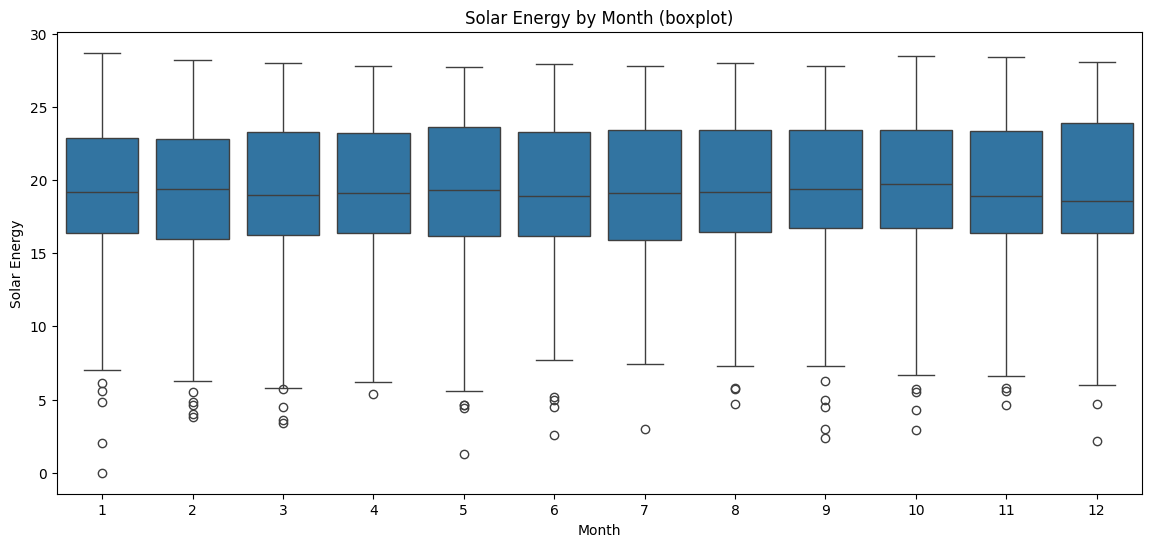

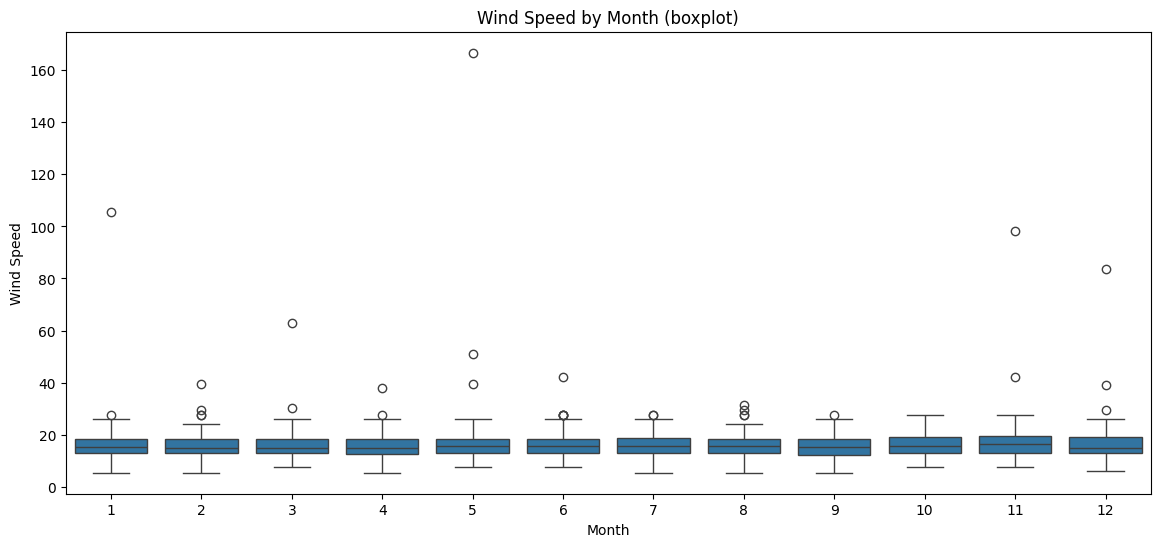

In [20]:
# add month column on original df
df = df.dropna(subset=[df.index.name])
df['month'] = df.index.month

plt.figure(figsize=(14,6))
sns.boxplot(x='month', y='solarenergy', data=df, order=range(1,13))
plt.title('Solar Energy by Month (boxplot)')
plt.xlabel('Month'); plt.ylabel('Solar Energy')
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(x='month', y='windspeed', data=df, order=range(1,13))
plt.title('Wind Speed by Month (boxplot)')
plt.xlabel('Month'); plt.ylabel('Wind Speed')
plt.show()

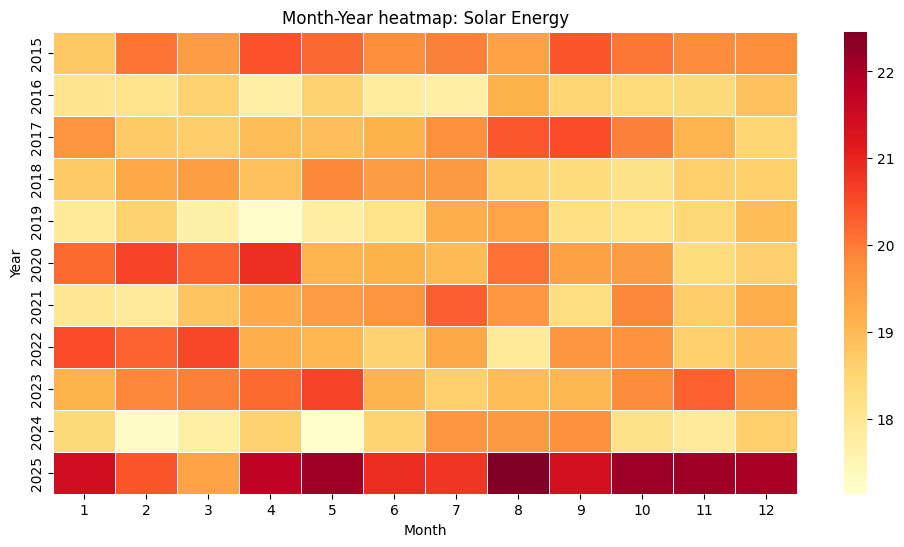

In [21]:
# pivot: years as rows, months as columns
monthly_pivot = monthly['solarenergy'].copy()
monthly_pivot = monthly_pivot.to_frame()
monthly_pivot['year'] = monthly_pivot.index.year
monthly_pivot['month'] = monthly_pivot.index.month
heat = monthly_pivot.pivot_table(index='year', columns='month', values='solarenergy')

plt.figure(figsize=(12,6))
sns.heatmap(heat, annot=False, cmap='YlOrRd', linewidths=.5)
plt.title('Month-Year heatmap: Solar Energy')
plt.xlabel('Month'); plt.ylabel('Year')
plt.show()

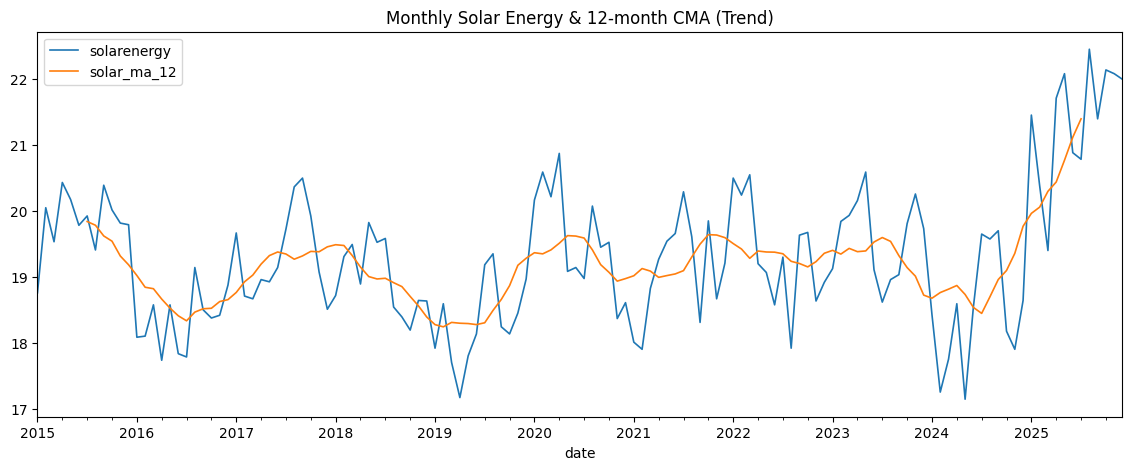

In [22]:
# 12-month moving average (centered CMA)
monthly['solar_ma_12'] = monthly['solarenergy'].rolling(window=12, center=True).mean()
monthly[['solarenergy','solar_ma_12']].plot(figsize=(14,5), linewidth=1.2)
plt.title('Monthly Solar Energy & 12-month CMA (Trend)')
plt.show()


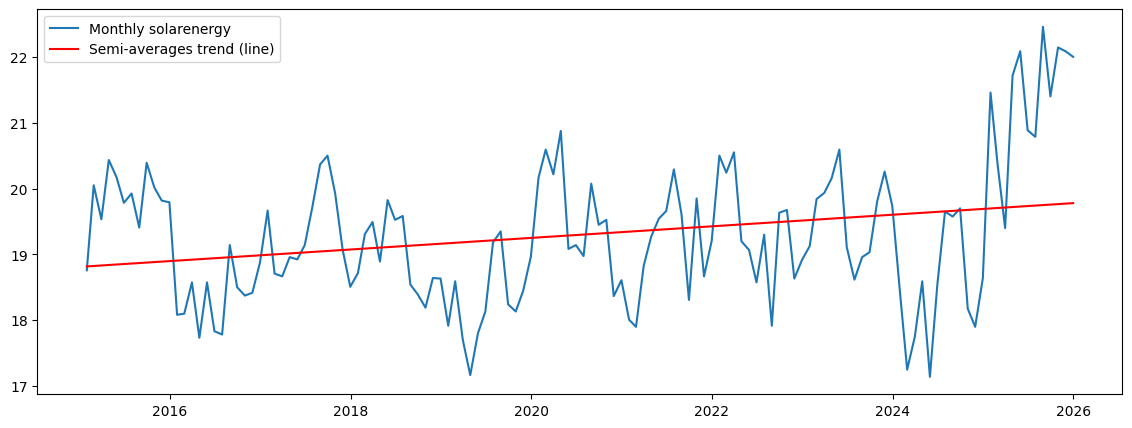

In [23]:
s = monthly['solarenergy'].dropna().copy()
n = len(s)
half = n//2

# means of halves
y1 = s.iloc[:half].mean()
y2 = s.iloc[half:].mean()

# time indices
t = np.arange(n)
x1 = t[:half].mean()
x2 = t[half:].mean()

slope = (y2 - y1) / (x2 - x1)
intercept = y1 - slope * x1
trend_semiavg = intercept + slope * t

# plot
plt.figure(figsize=(14,5))
plt.plot(s.index, s.values, label='Monthly solarenergy')
plt.plot(s.index, trend_semiavg, label='Semi-averages trend (line)', color='red')
plt.legend()
plt.show()


R2 linear: 0.08170949508187797 R2 quad: 0.2140461473265809 R2 exp (on positive subset): 0.08214535688416402


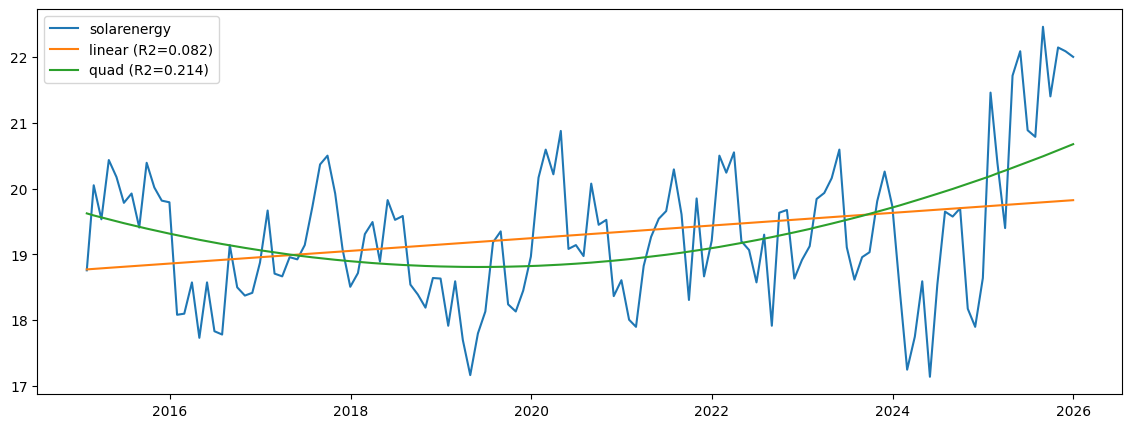

In [24]:
from sklearn.metrics import r2_score

s = monthly['solarenergy'].dropna()
t = np.arange(len(s))

# linear
lin_coef = np.polyfit(t, s.values, 1)
lin_fit = np.polyval(lin_coef, t)
r2_lin = r2_score(s.values, lin_fit)

# quadratic
quad_coef = np.polyfit(t, s.values, 2)
quad_fit = np.polyval(quad_coef, t)
r2_quad = r2_score(s.values, quad_fit)

# exponential: ln(y) = a + b t  (only if all y>0)
mask_pos = s>0
exp_coef = np.polyfit(t[mask_pos], np.log(s.values[mask_pos]), 1)
exp_fit = np.exp(np.polyval(exp_coef, t))
r2_exp = r2_score(s.values[mask_pos], exp_fit[mask_pos])

print("R2 linear:", r2_lin, "R2 quad:", r2_quad, "R2 exp (on positive subset):", r2_exp)

plt.figure(figsize=(14,5))
plt.plot(s.index, s.values, label='solarenergy')
plt.plot(s.index, lin_fit, label=f'linear (R2={r2_lin:.3f})')
plt.plot(s.index, quad_fit, label=f'quad (R2={r2_quad:.3f})')
plt.legend()
plt.show()


Variance before: 1.153080462787899  after detrending: 0.5530371648095681  reduction %: 52.038285041059154


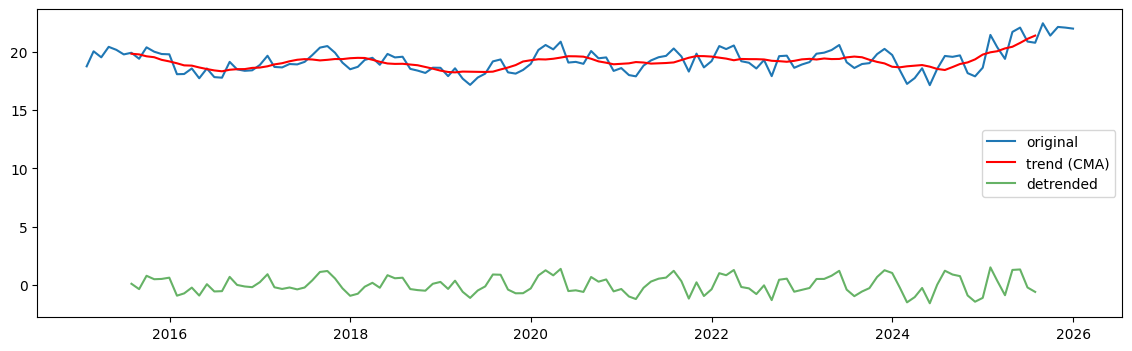

In [25]:
# choose trend (for example use CMA or the best-fit poly). Here use CMA for smooth trend:
trend_est = monthly['solar_ma_12'].reindex(monthly.index)  # aligned
detrended = monthly['solarenergy'] - trend_est

# compute reduction in variance
var_before = monthly['solarenergy'].var()
var_after  = detrended.dropna().var()
print("Variance before:", var_before, " after detrending:", var_after,
      " reduction %:", (1 - var_after/var_before)*100)

plt.figure(figsize=(14,4))
plt.plot(monthly.index, monthly['solarenergy'], label='original')
plt.plot(monthly.index, trend_est, label='trend (CMA)', color='red')
plt.plot(monthly.index, detrended, label='detrended', color='green', alpha=0.6)
plt.legend()
plt.show()


In [26]:
# Use detrended (additive) = actual - trend
df_seas = monthly.copy()
df_seas['detrended'] = (df_seas['solarenergy'] - df_seas['solar_ma_12']).dropna()
# group by month number
df_seas['month'] = df_seas.index.month
simple_avg = df_seas.groupby('month')['detrended'].mean()
# normalize (additive: mean should be ~0)
simple_avg


,detrended
month,
1,0.058740
2,-0.063075
3,-0.069554
4,0.066806
5,0.057063
6,-0.171012
7,0.140052
8,0.183829
9,0.101865


In [27]:
ratio_to_trend = (monthly['solarenergy'] / monthly['solar_ma_12']).dropna()
ratio_idx = ratio_to_trend.groupby(ratio_to_trend.index.month).mean()
# normalize to mean 1.0 or mean 100
ratio_idx_norm = ratio_idx / ratio_idx.mean() * 1.0
ratio_idx_norm


,0
date,
1,1.003077
2,0.996806
3,0.996674
4,1.002967
5,1.002702
6,0.991710
7,1.008578
8,1.010516
9,1.005702


In [28]:
# centered moving average already = solar_ma_12
ratios = (monthly['solarenergy'] / monthly['solar_ma_12']).dropna()
ri = ratios.groupby(ratios.index.month).mean()
ri_norm = ri / ri.mean() * 1.0  # if you want mean 1.0; multiply by 100 for percent
ri_norm


,0
date,
1,1.003077
2,0.996806
3,0.996674
4,1.002967
5,1.002702
6,0.991710
7,1.008578
8,1.010516
9,1.005702


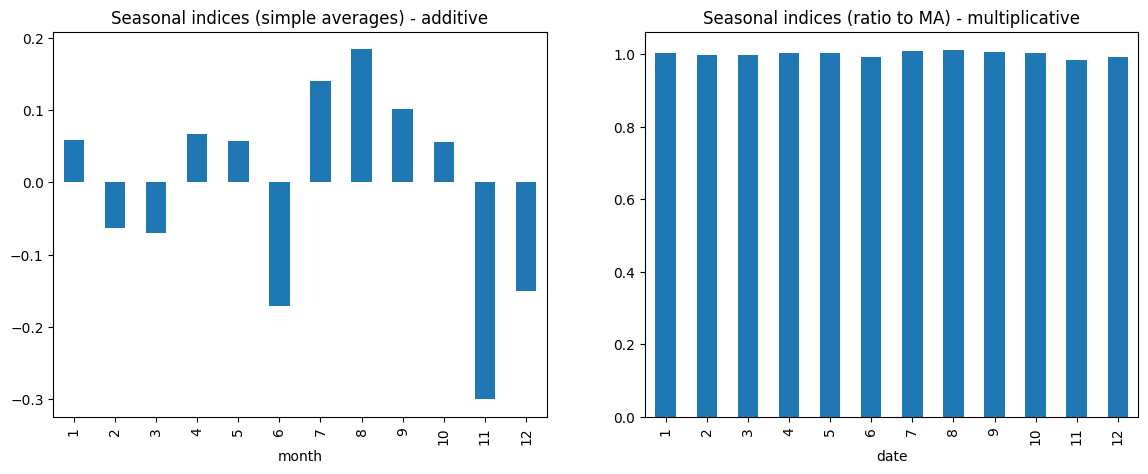

In [29]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
simple_avg.plot(kind='bar', ax=ax[0], title='Seasonal indices (simple averages) - additive')
ri_norm.plot(kind='bar', ax=ax[1], title='Seasonal indices (ratio to MA) - multiplicative')
plt.show()


<Figure size 1200x400 with 0 Axes>

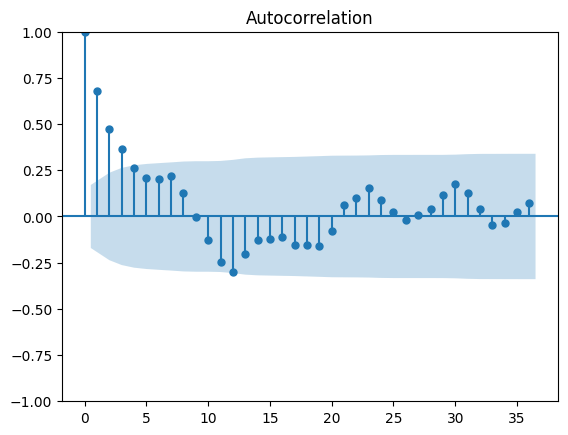

<Figure size 1200x400 with 0 Axes>

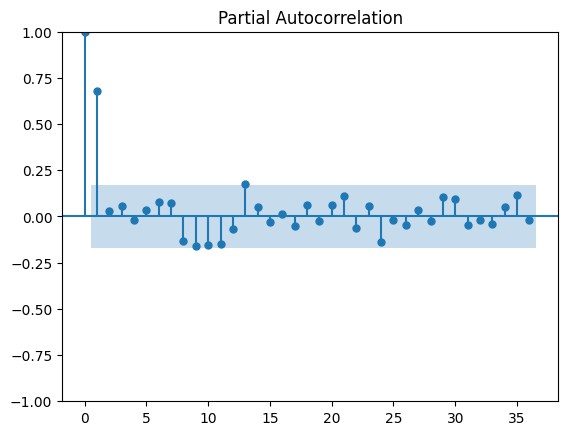

ADF stat = -4.428361159843285 p-value = 0.0002643435497157266


In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ACF / PACF for monthly solar
plt.figure(figsize=(12,4))
plot_acf(monthly['solarenergy'].dropna(), lags=36, alpha=0.05)
plt.show()
plt.figure(figsize=(12,4))
plot_pacf(monthly['solarenergy'].dropna(), lags=36, alpha=0.05)
plt.show()

# ADF test
adf_res = adfuller(monthly['solarenergy'].dropna())
print('ADF stat =', adf_res[0], 'p-value =', adf_res[1])


/tmp/ipython-input-444912445.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['daylight_hours'] = df['daylight'].str.split(':').apply(lambda x: int(x[0]) + int(x[1])/60 + int(x[2])/3600)


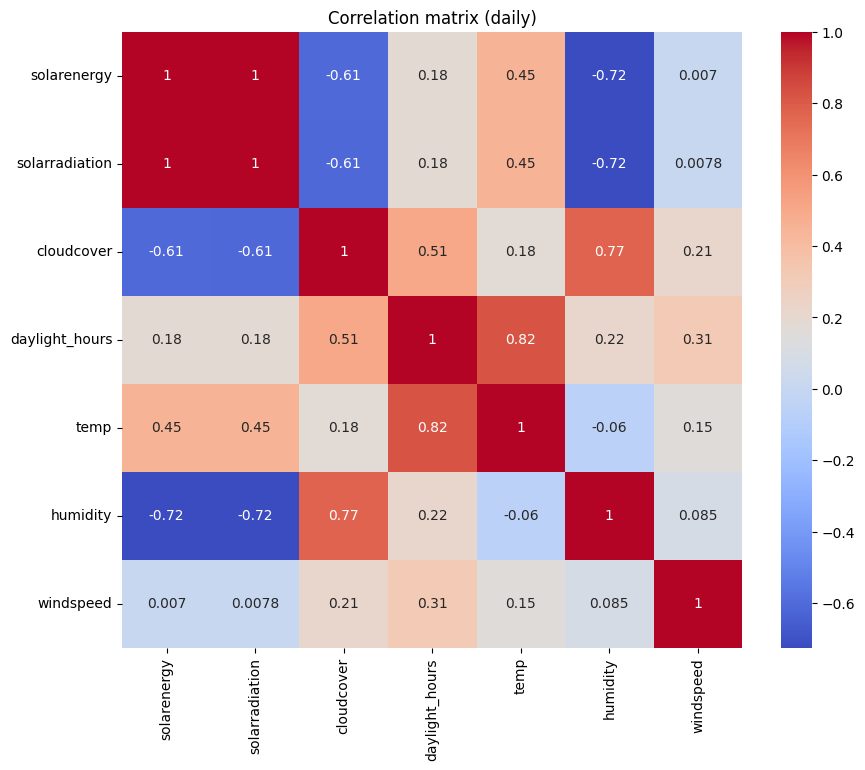

/tmp/ipython-input-444912445.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  a = df['solarenergy'].fillna(method='ffill')
/tmp/ipython-input-444912445.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  b = df['cloudcover'].fillna(method='ffill')


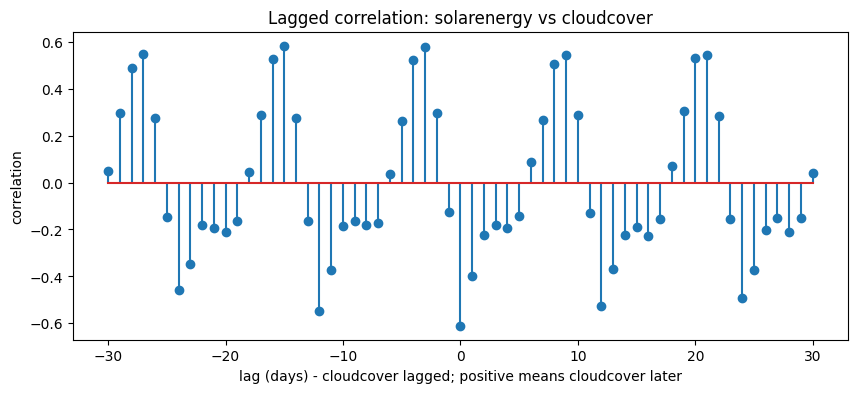

In [34]:
# Convert 'daylight' column to total hours (numeric)
df['daylight_hours'] = df['daylight'].str.split(':').apply(lambda x: int(x[0]) + int(x[1])/60 + int(x[2])/3600)

# Correlation matrix (daily or monthly)
corr_daily = df[['solarenergy','solarradiation','cloudcover','daylight_hours','temp','humidity','windspeed']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_daily, annot=True, cmap='coolwarm')
plt.title('Correlation matrix (daily)')
plt.show()

# Lagged cross-correlation example: solarenergy vs cloudcover
from statsmodels.tsa.stattools import ccf
a = df['solarenergy'].ffill()
b = df['cloudcover'].ffill()
# compute cross-corr for small lags manually (note: normalize)
lags = np.arange(-30,31)
ccs = [a.corr(b.shift(l)) for l in lags]
plt.figure(figsize=(10,4))
plt.stem(lags, ccs)
plt.xlabel("lag (days) - cloudcover lagged; positive means cloudcover later")
plt.ylabel("correlation")
plt.title("Lagged correlation: solarenergy vs cloudcover")
plt.show()

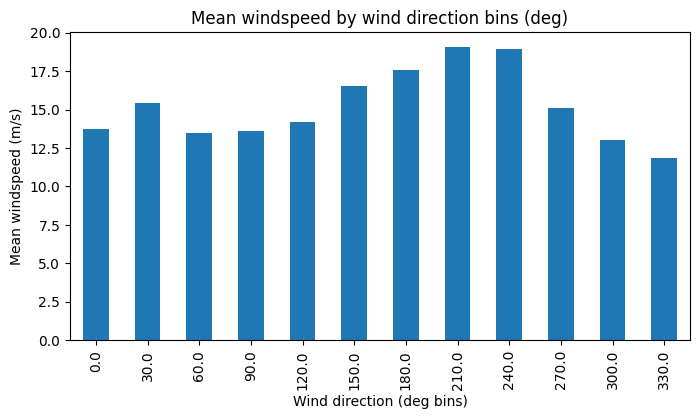

In [35]:
# simplistic windrose: mean windspeed by direction bins
if 'winddir' in df.columns and 'windspeed' in df.columns:
    wd = df[['winddir','windspeed']].dropna()
    wd['dir_bin'] = (wd['winddir']//30)*30  # 12 bins
    windrose = wd.groupby('dir_bin')['windspeed'].mean().reindex(sorted(wd['dir_bin'].unique()))
    plt.figure(figsize=(8,4))
    windrose.plot(kind='bar')
    plt.title('Mean windspeed by wind direction bins (deg)')
    plt.xlabel('Wind direction (deg bins)')
    plt.ylabel('Mean windspeed (m/s)')
    plt.show()


In [37]:
from google.colab import files

# Save your dataframe to CSV
df.to_csv('processed_data.csv', index=True)

# Download to your local machine
files.download('processed_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>